# Preparing a Model for Deployment: The Full Save/Load/Predict Cycle

Deployment is not just saving a model file. A real deployment artifact is a bundle: the trained pipeline, the preprocessing transformations, and a metadata file describing what the model is and what it expects. This notebook builds that bundle from scratch and verifies it works correctly after loading.

**Learning objectives**
1. Understand what files a deployment artifact must contain beyond just the model weights.
2. Build a `sklearn.Pipeline` that combines preprocessing and a classifier in one object.
3. Save the pipeline with joblib, delete it from memory, reload it, and verify predictions are identical.
4. Save a metadata JSON alongside the model and write a `load_model_bundle()` function that validates it.

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 1, lesson 03 "03. Data Preprocessing" — the `StandardScaler` and `OneHotEncoder` you fitted on training data have to travel with the model; a deployment that reloads only the estimator transforms production inputs differently and fails silently.


## 📰 A missing unit label destroyed a Mars orbiter

On **23 September 1999** NASA lost the **Mars Climate Orbiter**. The spacecraft was healthy, the navigation mathematics was correct, and the software on both sides ran exactly as written. The problem was the interface between them: the ground software supplied thruster impulse in **pound-force seconds**, while the navigation software expected **newton-seconds** — a factor of **4.45**. The Mishap Investigation Board's Phase I report records the consequence precisely: the first periapsis was planned at **226 km** and came out at **57 km**, "which was judged too low for spacecraft survival". The orbiter was destroyed in the Martian atmosphere.

*A note on the price tag.* You will often see "$327 million" attached to this accident. JPL's own Mars '98 launch press kit gives the project cost as **$193.1 M spacecraft development plus $42.8 M mission operations — $235.9 million for the orbiter and lander together**, excluding launch vehicles. The larger number is the whole Mars '98 programme including both launches, not this one spacecraft. Check the figure you quote.

Nothing in this notebook is about spacecraft. Everything in it is about the same failure mode: **a numeric array is meaningless without the description of what its columns are and what units they are in**, and a model file alone carries no such description. `joblib.load()` hands you an object that will happily predict from a scrambled or mis-scaled row and return a confident answer.

**What goes wrong without this lesson.** The single most common ML deployment bug is shipping the estimator without the fitted preprocessing — the scaler stays in the training notebook, the server feeds raw features straight into a model trained on standardized ones, and *nothing errors*. Accuracy quietly collapses while every dashboard stays green. Bundling the scaler inside the pipeline makes that bug impossible to write; the metadata file makes the remaining assumptions inspectable six months later.

## 1  What does a deployment artifact need?

A model in production needs three things:

| File | Purpose |
|------|--------|
| `pipeline.joblib` | The trained model + all preprocessing steps |
| `metadata.json` | Version, feature names, accuracy, training date |
| `requirements.txt` | Exact package versions the model was trained with |

If you save the model but not the scaler, predictions will be wrong. If you save the model but not the metadata, you have no way to check whether the file on the server is the one you intended to deploy.


In [1]:
# WHAT: load iris, keep the human-readable feature/class names, and split the data.
# WHY: a deployable model needs more than weights — the names captured here become
# part of the model's metadata so the serving side can label inputs and outputs.
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import numpy as np
import joblib
import json
import os
from datetime import datetime

iris = load_iris()
FEATURE_NAMES = list(iris.feature_names)
CLASS_NAMES = list(iris.target_names)

# Hold out 20% so the accuracy stored in metadata is an honest holdout number.
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

# Print what will go into metadata — students should recognize these later.
print("Feature names:", FEATURE_NAMES)
print("Class names  :", CLASS_NAMES)
print(f"Training samples: {len(X_train)}   Test samples: {len(X_test)}")

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class names  : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Training samples: 120   Test samples: 30


## 2  Build a preprocessing pipeline

Wrapping the scaler and classifier in a `Pipeline` means you only have to call `pipeline.predict(raw_features)` — the pipeline applies the scaler automatically. This is what you should always save: the whole pipeline, not just the classifier.


In [2]:
# WHAT: bundle preprocessing + model into ONE sklearn Pipeline and train it.
# WHY: if the scaler is saved separately from the model, serving code can forget it —
# the classic train/serve skew bug. One pipeline object makes that impossible.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

# Fitting the pipeline fits the scaler AND the forest in the right order.
pipeline.fit(X_train, y_train)
accuracy = pipeline.score(X_test, y_test)

# Reference predictions — we'll verify the loaded pipeline produces the same values
reference_preds = pipeline.predict(X_test)

# The scaler mean proves preprocessing parameters live inside the artifact.
print(f"Pipeline accuracy: {accuracy:.2%}")
print(f"Steps in pipeline: {[s[0] for s in pipeline.steps]}")
print(f"Scaler mean (first feature): {pipeline.named_steps['scaler'].mean_[0]:.4f}")

Pipeline accuracy: 100.00%
Steps in pipeline: ['scaler', 'classifier']
Scaler mean (first feature): 5.8092


## 3  Save the pipeline with joblib


In [3]:
# WHAT: save the whole pipeline into a dedicated bundle directory.
# WHY: one folder = one deployable unit; the metadata file will sit next to the
# model so they can never be shipped separately.
BUNDLE_DIR = "/tmp/iris_model_bundle"
os.makedirs(BUNDLE_DIR, exist_ok=True)

PIPELINE_PATH = os.path.join(BUNDLE_DIR, "pipeline.joblib")
joblib.dump(pipeline, PIPELINE_PATH)

# Report the artifact size — deployment systems care about download/startup cost.
size_kb = os.path.getsize(PIPELINE_PATH) / 1024
print(f"Pipeline saved to: {PIPELINE_PATH}")
print(f"File size: {size_kb:.1f} KB")

Pipeline saved to: /tmp/iris_model_bundle/pipeline.joblib
File size: 183.1 KB


## 4  Load fresh and verify identical predictions

We delete the original object from memory (simulating a fresh server), reload from disk, and confirm predictions are bit-for-bit identical to the reference.


In [4]:
# Delete the original pipeline to simulate a fresh environment
del pipeline

# Reload from disk
loaded_pipeline = joblib.load(PIPELINE_PATH)

loaded_preds = loaded_pipeline.predict(X_test)
match = np.array_equal(loaded_preds, reference_preds)

print(f"Predictions match original: {match}")
print(f"Loaded pipeline accuracy  : {loaded_pipeline.score(X_test, y_test):.2%}")
print(f"Scaler mean still intact  : {loaded_pipeline.named_steps['scaler'].mean_[0]:.4f}")

# Confirm the scaler is embedded — raw features go in, correct predictions come out
sample_raw = X_test[:3]
print(f"\nSample predictions on raw features (scaler applied inside pipeline):")
for i, pred in enumerate(loaded_pipeline.predict(sample_raw)):
    print(f"  Sample {i}: {CLASS_NAMES[pred]}")


Predictions match original: True
Loaded pipeline accuracy  : 100.00%
Scaler mean still intact  : 5.8092

Sample predictions on raw features (scaler applied inside pipeline):
  Sample 0: versicolor
  Sample 1: setosa
  Sample 2: virginica


### 4.1  The bug the bundle prevents, measured

The Mars Climate Orbiter note at the top of this notebook claims that shipping the estimator *without* its fitted scaler fails silently. Do not take that on trust — run it. The cell below pulls the classifier out of the loaded pipeline (exactly what a server does when someone saves `pipeline.named_steps["classifier"]` instead of the pipeline) and feeds it the same raw centimetre values, on the same 30 test rows.

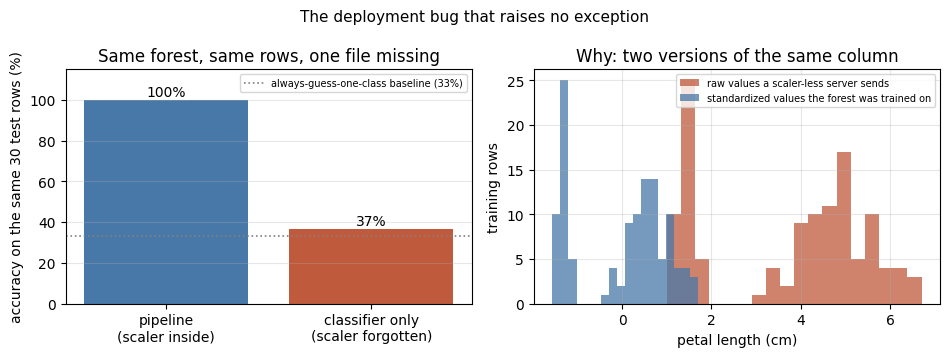

Full pipeline      : 100.00% accuracy
Scaler forgotten   : 36.67% accuracy
Exception raised   : none - it returned 30 well-formed predictions
What it predicted  : {np.str_('virginica'): 30}
True labels        : {np.str_('versicolor'): 9, np.str_('setosa'): 10, np.str_('virginica'): 11}


In [5]:
# WHAT: score the same test rows twice - once through the whole pipeline, once
# through the classifier alone with the scaler skipped.
# WHY: this is the most common ML deployment bug on record, and its signature is
# that NOTHING raises. The server returns well-formed predictions the whole time.
import collections

import matplotlib.pyplot as plt

# The right way: the pipeline scales, then predicts.
bundle_acc = loaded_pipeline.score(X_test, y_test)

# The bug: someone saved only the estimator, so raw cm values reach a forest whose
# split thresholds were learned in standardized units.
classifier_only = loaded_pipeline.named_steps["classifier"]
naked_preds = classifier_only.predict(X_test)          # no exception, no warning
naked_acc = float(np.mean(naked_preds == y_test))

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.6))

ax = axes[0]
vals = [bundle_acc * 100, naked_acc * 100]
bars = ax.bar(["pipeline\n(scaler inside)", "classifier only\n(scaler forgotten)"],
              vals, color=["#4878a8", "#c05a3c"])
ax.axhline(100 / 3, color="grey", ls=":", lw=1.2,
           label="always-guess-one-class baseline (33%)")
ax.legend(loc="upper right", fontsize=7)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 2, f"{v:.0f}%", ha="center", fontsize=10)
ax.set_ylim(0, 115)
ax.set_ylabel("accuracy on the same 30 test rows (%)")
ax.set_title("Same forest, same rows, one file missing")
ax.grid(axis="y", alpha=0.3)

# Why it happens: the column the forest was trained on is not the column it is now fed.
ax = axes[1]
col = 2                                                # petal length (cm)
scaled_train = loaded_pipeline.named_steps["scaler"].transform(X_train)
ax.hist(X_train[:, col], bins=18, color="#c05a3c", alpha=0.75,
        label="raw values a scaler-less server sends")
ax.hist(scaled_train[:, col], bins=18, color="#4878a8", alpha=0.75,
        label="standardized values the forest was trained on")
ax.set_xlabel(FEATURE_NAMES[col])
ax.set_ylabel("training rows")
ax.set_title("Why: two versions of the same column")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

fig.suptitle("The deployment bug that raises no exception", fontsize=11)
plt.tight_layout()
plt.show()

print(f"Full pipeline      : {bundle_acc:.2%} accuracy")
print(f"Scaler forgotten   : {naked_acc:.2%} accuracy")
print(f"Exception raised   : none - it returned {naked_preds.shape[0]} well-formed predictions")
print(f"What it predicted  : {dict(collections.Counter(CLASS_NAMES[p] for p in naked_preds))}")
print(f"True labels        : {dict(collections.Counter(CLASS_NAMES[p] for p in y_test))}")

**Read the figure.** Left: two bars from the *same* trained forest on the *same* 30 rows. The only difference is whether the fitted `StandardScaler` travelled with it. The right-hand bar collapses to around the level of a model that always shouts one class — and the printed class counts confirm that is literally what happens: every row comes back as the same species.

Right: the reason. A `StandardScaler` moves petal length from roughly 1–7 cm to roughly −1.5 to +1.8. The forest learned its split thresholds in the blue distribution. A server that forgot the scaler hands it the red one, where nearly every value sits above every threshold the tree ever learned, so every row falls the same way down the tree.

Now the part that should make you uncomfortable: **no exception was raised.** Shapes matched, dtypes matched, the API returned 30 well-formed predictions with confidences attached. A monitoring dashboard watching for errors, timeouts or 500s would have stayed green the entire time. That is what "fails silently" means, and it is the entire argument for saving one `Pipeline` object instead of a model plus a mental note about preprocessing.

## 5  Save model metadata as JSON

The metadata file records what this model is, what it was trained on, and how well it performed. Without this file, you cannot tell which version of the model is running in production.


In [6]:
# WHAT: write a metadata.json next to the model with version, date, accuracy, schema.
# WHY: six months from now nobody remembers what 'pipeline.joblib' is — metadata
# makes the artifact self-describing, auditable, and safe to roll back.
import sklearn

# Everything a future engineer (or an automated gate) needs to trust this model.
metadata = {
    "model_name": "iris-classifier",
    "version": "1.0.0",
    "training_date": datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),
    "feature_names": FEATURE_NAMES,
    "class_names": list(CLASS_NAMES),
    "n_features": len(FEATURE_NAMES),
    "n_classes": len(CLASS_NAMES),
    "test_accuracy": round(loaded_pipeline.score(X_test, y_test), 4),
    "sklearn_version": sklearn.__version__,
    "pipeline_steps": [s[0] for s in loaded_pipeline.steps],
}

# JSON, not pickle: metadata must be readable without Python or sklearn.
METADATA_PATH = os.path.join(BUNDLE_DIR, "metadata.json")
with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print("Metadata saved:")
print(json.dumps(metadata, indent=2))

Metadata saved:
{
  "model_name": "iris-classifier",
  "version": "1.0.0",
  "training_date": "2026-08-29T19:26:53Z",
  "feature_names": [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
  ],
  "class_names": [
    "setosa",
    "versicolor",
    "virginica"
  ],
  "n_features": 4,
  "n_classes": 3,
  "test_accuracy": 1.0,
  "sklearn_version": "1.8.0",
  "pipeline_steps": [
    "scaler",
    "classifier"
  ]
}


/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_41224/2660466530.py:10: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "training_date": datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),


## 6  Load the full model bundle

A deployment system should load both files together and validate that the metadata is consistent before serving any traffic.


In [7]:
# WHAT: a loader that refuses to return a model unless the bundle is complete and
# consistent (files exist, feature counts agree between metadata and model).
# WHY: failing loudly at load time is far cheaper than serving wrong predictions —
# this is the receiving end of the packaging contract we just wrote.
def load_model_bundle(bundle_dir):
    """Load a model pipeline and its metadata, with basic validation."""
    pipeline_path = os.path.join(bundle_dir, "pipeline.joblib")
    metadata_path = os.path.join(bundle_dir, "metadata.json")

    if not os.path.exists(pipeline_path):
        raise FileNotFoundError(f"pipeline.joblib not found in {bundle_dir}")
    if not os.path.exists(metadata_path):
        raise FileNotFoundError(f"metadata.json not found in {bundle_dir}")

    model = joblib.load(pipeline_path)
    with open(metadata_path) as f:
        meta = json.load(f)

    # Validate that the model expects the right number of features
    expected_features = meta["n_features"]
    scaler = model.named_steps["scaler"]
    actual_features = scaler.n_features_in_
    if expected_features != actual_features:
        raise ValueError(
            f"Metadata says {expected_features} features, "
            f"but model has {actual_features}"
        )

    return model, meta


# Load the bundle
model, meta = load_model_bundle(BUNDLE_DIR)

print(f"Loaded model    : {meta['model_name']} v{meta['version']}")
print(f"Trained on      : {meta['training_date']}")
print(f"Feature names   : {meta['feature_names']}")
print(f"Test accuracy   : {meta['test_accuracy']:.2%}")

# Confirm predictions still match
# Final proof: the loaded bundle predicts exactly like the pipeline we trained.
bundle_preds = model.predict(X_test)
print(f"\nPredictions match reference: {np.array_equal(bundle_preds, reference_preds)}")

Loaded model    : iris-classifier v1.0.0
Trained on      : 2026-08-29T19:26:53Z
Feature names   : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Test accuracy   : 100.00%

Predictions match reference: True


### 6.1  What the validation actually validates

`load_model_bundle()` just returned a model and its metadata, and printed a version, a date and an accuracy. That output looks like verification. It is worth finding out how much of it is.

The cell below makes four damaged copies of the bundle — one per way a real deployment folder goes wrong — hands each to the *same* loader, and records both what the loader did and, for the bundles it accepted, whether the accuracy in `metadata.json` is still true of the model sitting next to it.

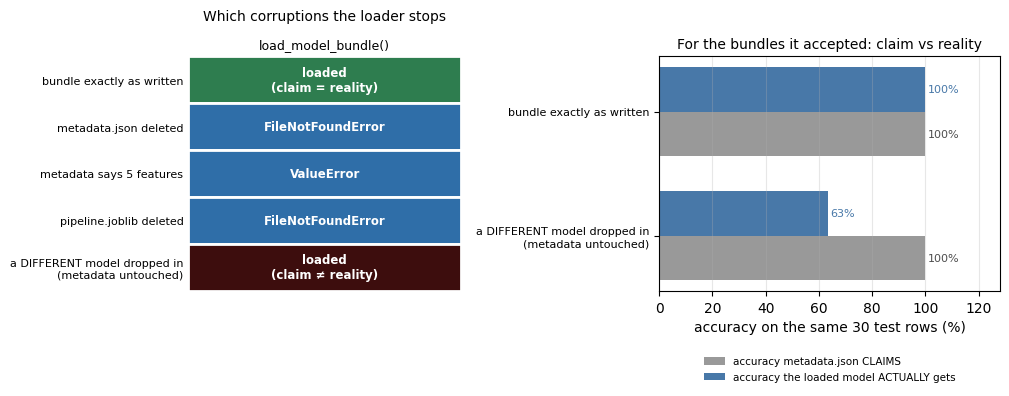

scenario                                 loader                  claimed  measured
bundle exactly as written                loaded                     100%      100%
metadata.json deleted                    refused (FileNotFoundError)        -         -
metadata says 5 features                 refused (ValueError)          -         -
pipeline.joblib deleted                  refused (FileNotFoundError)        -         -
a DIFFERENT model dropped in (metadata u loaded                     100%       63%


In [8]:
# WHAT: corrupt a copy of the bundle four different ways, run each through
# load_model_bundle(), and compare the metadata's claim against a measurement.
# WHY: a validator is defined by what it lets through, not by what it stops. The
# only way to know which is which is to break the bundle on purpose.
import shutil

import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

def make_copy(tag):
    """A throwaway copy of the good bundle, so the original is never damaged."""
    d = f"/tmp/iris_bundle_{tag}"
    shutil.rmtree(d, ignore_errors=True)
    shutil.copytree(BUNDLE_DIR, d)
    return d

# --- five bundles: the good one, and four ways a deployment folder goes wrong ---
def intact(d):
    pass                                                # the control

def drop_metadata(d):
    os.remove(os.path.join(d, "metadata.json"))         # release script missed a file

def claim_five_features(d):                             # metadata edited, model not retrained
    path = os.path.join(d, "metadata.json")
    m = json.load(open(path)); m["n_features"] = 5
    json.dump(m, open(path, "w"), indent=2)

def drop_pipeline(d):
    os.remove(os.path.join(d, "pipeline.joblib"))       # the copy failed halfway

def swap_in_another_model(d):
    """Overwrite the artifact, leave metadata.json alone - the honour-system case.
    Same 4 features, same 3 classes, same pipeline steps: nothing structural differs."""
    other = Pipeline([("scaler", StandardScaler()),
                      ("classifier", DecisionTreeClassifier(max_depth=1, random_state=0))])
    other.fit(X_train, y_train)
    joblib.dump(other, os.path.join(d, "pipeline.joblib"))

SCENARIOS = [
    ("bundle exactly as written",                       intact),
    ("metadata.json deleted",                           drop_metadata),
    ("metadata says 5 features",                        claim_five_features),
    ("pipeline.joblib deleted",                         drop_pipeline),
    ("a DIFFERENT model dropped in\n(metadata untouched)", swap_in_another_model),
]

results = []
for tag, (label, damage) in enumerate(SCENARIOS):
    d = make_copy(tag)
    damage(d)
    try:
        m, md = load_model_bundle(d)                    # the same loader, unchanged
        results.append((label, None, float(md["test_accuracy"]), float(m.score(X_test, y_test))))
    except Exception as exc:                            # refusing IS the good outcome
        results.append((label, type(exc).__name__, None, None))

# --- left: what the loader did. right: for what it accepted, claim vs reality ---
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.3), gridspec_kw={"width_ratios": [1, 1.25]})
n = len(results)

ax = axes[0]
for i, (label, err, claimed, actual) in enumerate(results):
    refused = err is not None
    honest = (not refused) and abs(claimed - actual) < 1e-9
    color = "#2f6ea8" if refused else ("#2e7d4f" if honest else "#3d0d0d")
    text = err if refused else ("loaded\n(claim = reality)" if honest else "loaded\n(claim \u2260 reality)")
    ax.add_patch(plt.Rectangle((0, n - 1 - i), 1, 1, facecolor=color, edgecolor="white", lw=2))
    ax.text(0.5, n - 0.5 - i, text, ha="center", va="center",
            color="white", fontsize=8.5, fontweight="bold")
ax.set_xlim(0, 1); ax.set_ylim(0, n)
ax.set_xticks([0.5]); ax.set_xticklabels(["load_model_bundle()"], fontsize=9)
ax.set_yticks([n - 0.5 - i for i in range(n)])
ax.set_yticklabels([r[0] for r in results], fontsize=8)
ax.xaxis.set_ticks_position("top")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)
ax.set_title("Which corruptions the loader stops", fontsize=10, pad=26)

ax = axes[1]
accepted = [r for r in results if r[1] is None]
y = np.arange(len(accepted)); h = 0.36
ax.barh(y + h / 2, [r[2] * 100 for r in accepted], height=h, color="0.6",
        label="accuracy metadata.json CLAIMS")
ax.barh(y - h / 2, [r[3] * 100 for r in accepted], height=h, color="#4878a8",
        label="accuracy the loaded model ACTUALLY gets")
for yi, r in enumerate(accepted):
    ax.text(r[2] * 100 + 1, yi + h / 2, f"{r[2]:.0%}", va="center", fontsize=8, color="0.3")
    ax.text(r[3] * 100 + 1, yi - h / 2, f"{r[3]:.0%}", va="center", fontsize=8, color="#4878a8")
ax.set_yticks(y); ax.set_yticklabels([r[0] for r in accepted], fontsize=8)
ax.invert_yaxis()
ax.set_xlim(0, 128)
ax.set_xlabel("accuracy on the same 30 test rows (%)")
ax.set_title("For the bundles it accepted: claim vs reality", fontsize=10)
ax.legend(fontsize=7.5, loc="upper center", bbox_to_anchor=(0.5, -0.24), ncol=1, frameon=False)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'scenario':40s} {'loader':22s} {'claimed':>8s} {'measured':>9s}")
for label, err, claimed, actual in results:
    flat = label.replace("\n", " ")
    verdict = f"refused ({err})" if err else "loaded"
    c = f"{claimed:.0%}" if claimed is not None else "-"
    a = f"{actual:.0%}" if actual is not None else "-"
    print(f"{flat:40.40s} {verdict:22s} {c:>8s} {a:>9s}")

**Read the figure.** The left column is the loader's verdict on five bundles. Three are blue: a missing `metadata.json`, a missing `pipeline.joblib`, and a metadata file claiming five features for a four-feature model all raise before anything is returned. That is `load_model_bundle()` doing exactly what it was written to do — refusing at load time is cheap, and every one of these is a real release-script failure.

The bottom row is the one to stop on. A different model — a depth-1 decision tree instead of the hundred-tree forest — was written over `pipeline.joblib` and `metadata.json` was not touched. It has four features, three classes, the same two pipeline steps, and it loads without complaint. The right panel measures the consequence: the metadata still claims **100%**, and the model that actually loaded scores **63%** on the same thirty rows. Grey bar and blue bar agree perfectly on the intact bundle and disagree by 37 points on the swapped one.

So the printed line `Test accuracy: 100.00%` in the cell above is not a measurement — it is a **quotation from a file that nobody verified**. Every check in this loader is structural: does the file exist, do the shapes agree. None of them ties the metadata to *this* artifact.

Two fixes, in increasing order of strength, and both are in this diploma:

1. Store a **hash of `pipeline.joblib`** inside `metadata.json` and check it on load. Cheap, and it catches the swap immediately.
2. Re-run a small **golden batch** of known rows through the loaded model at startup and compare the answers to stored expectations (Unit 2). A hash proves you loaded the same bytes; a golden batch proves those bytes still behave.

This is the "honour system" bullet in "⚠️ Where this breaks" below, with a number attached to it.

## 💬 Discuss

The reload check printed `Predictions match original: True` and `Scaler mean still intact: 5.8092` — the same number as before the save. That is the comparison this notebook rests on: **save → delete from memory → reload → identical predictions**. Now push on what it does and does not prove.

1. `np.array_equal(loaded_preds, reference_preds)` compares *class labels*. Would it still print `True` if the reloaded scaler had subtly different floating-point internals, or if `predict_proba` had shifted by 0.01 across the board? What would you compare instead, and is the stricter check worth its false alarms?
2. Our `metadata.json` records `sklearn_version` but the loader never checks it. Should `load_model_bundle()` *refuse* to load a bundle built by a different scikit-learn version, *warn*, or *ignore* it? Argue it as the person on call at 2 a.m., then argue it again as the person trying to ship a hotfix.
3. The metadata stores `test_accuracy: 1.0`. Six months from now, that number is the only evidence anyone has about this model's quality. What would you add to the file so that a future colleague can tell whether 100% is impressive or a warning sign?

## Summary

A deployment artifact is a bundle, not just a model file. The three required components are:

| Component | Why it matters |
|---|---|
| `pipeline.joblib` (with scaler embedded) | The model and all preprocessing in one object — raw input goes in, prediction comes out |
| `metadata.json` | Records version, features, accuracy — makes deployments auditable |
| Verification step | Confirms the loaded model gives the same predictions as the original |

Saving the classifier without the scaler is a common mistake that causes incorrect predictions in production because the input distribution at inference time won't match what the model was trained on.


## Self-check

1. **What goes wrong if you save only the classifier but not the scaler?** Run `model.predict(X_test)` after removing the scaler step and observe the difference in predictions.
2. **What should you store in the metadata JSON?** Look at the metadata dict in Section 5 — which fields would you need to debug a model behaving unexpectedly in production?
3. **How would you check that the loaded model gives the same predictions as the original?** Look at the `np.array_equal(loaded_preds, reference_preds)` check in Section 4 — what would a `False` result tell you?


## ⚠️ Where this breaks

- **A hash-free bundle is an honour system.** Nothing here binds `pipeline.joblib` to `metadata.json`. Copy a newer model into the folder and the loader will keep reporting the old version, the old accuracy and the old feature names — with complete confidence. Unit 5 notebook 06 adds the data hash and git commit that close this gap; until then, treat the metadata as documentation, not as verification.
- **`Pipeline` protects you from *forgetting* preprocessing, not from *changing* it.** If the production feature pipeline upstream starts computing `mean area` differently, the model receives numbers that are correctly *shaped* and wrong in *meaning* — the Mars Climate Orbiter failure, in tabular form. No amount of bundling detects that. Only comparing live input distributions against the training baseline does (Unit 5, notebook 04).
- **The assumption that must hold:** the environment that loads the bundle can reconstruct every class inside it. A `joblib` file stores references, not code. Custom transformers, lambdas, and anything defined in a notebook cell will fail to unpickle elsewhere — often with an unhelpful `AttributeError`. If your pipeline contains custom steps, they must live in an importable module that ships with the service.
- **`utcnow()` and other silent metadata rot.** The cell above emits a `DeprecationWarning` for `datetime.utcnow()`, and the timestamp it writes has no timezone. In an audit trail, an ambiguous timestamp is close to no timestamp. Metadata is only as trustworthy as its least careful field.
- **The cheaper alternative.** If you are already using MLflow or another registry (Unit 5, notebook 05), it stores the artifact, the parameters, the metrics and the environment for you, and a hand-rolled `metadata.json` becomes a second source of truth that will drift from the first. Hand-roll this only when you genuinely have no registry.

## 🔭 State of the field (2026)

Writing version, date, accuracy and feature schema next to the artifact is still the right instinct, and in
2026 that file has a standard shape and a name — the model card, proposed so that intended use and
evaluation conditions travel with the model (Mitchell et al., 2019, arXiv:1810.03993). What changed is its
status. For systems in scope of the EU AI Act, documentation is an obligation rather than a courtesy, and
those obligations have been translated into a runnable benchmarking suite, so a model can now be tested
against a technical interpretation of the regulation instead of only read against it (Guldimann et al.,
2024, arXiv:2410.07959).

So keep hand-writing `metadata.json` here. Every registry, card generator and conformity report is filling
in these same fields, and you cannot audit a generated card if you have never written one by hand. The
bundle this notebook builds — pipeline, metadata, verification step — is what the official plan examines,
and Unit 5 turns it into a tracked, hashed record.

## 📚 References

1. Sculley, D., Holt, G., Golovin, D., et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS 28. <https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html>
2. Olston, C., Fiedel, N., Gorovoy, K., et al. (2017). *TensorFlow-Serving: Flexible, High-Performance ML Serving*. NeurIPS Workshop on ML Systems. <https://arxiv.org/abs/1712.06139>
3. Kreuzberger, D., Kühl, N., & Hirschl, S. (2022). *Machine Learning Operations (MLOps): Overview, Definition, and Architecture*. IEEE Access. <https://arxiv.org/abs/2205.02302>
4. Mitchell, M., Wu, S., Zaldivar, A., et al. (2019). *Model Cards for Model Reporting*. FAT* '19. arXiv:1810.03993. <https://arxiv.org/abs/1810.03993>
5. Guldimann, P., Spiridonov, A., Staab, R., et al. (2024). *COMPL-AI Framework: A Technical Interpretation and LLM Benchmarking Suite for the EU Artificial Intelligence Act*. arXiv:2410.07959. <https://arxiv.org/abs/2410.07959>
